In [1]:
%load_ext autoreload

In [2]:
import pandas as pd
from ast import literal_eval
import protfasta
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob, os
from tqdm import tqdm

os.chdir("../../consensus_AD_predictor/notebooks/")
%aimport ADpred_LambertTFs_helper

In [4]:
output_folder = "/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/collaborations/GrENEnet_TF_hits/15_cam5_predictor_results/"
output_folder

'/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/collaborations/GrENEnet_TF_hits/15_cam5_predictor_results/'

In [5]:
glob.glob(output_folder + "*")

['/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/collaborations/GrENEnet_TF_hits/15_cam5_predictor_results/12_cam5_ADHunter_preds_dask.csv',
 '/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/collaborations/GrENEnet_TF_hits/15_cam5_predictor_results/12_cam5_Paddle_preds_dask.csv',
 '/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/collaborations/GrENEnet_TF_hits/15_cam5_predictor_results/12_cam5_ADpred_preds_dask.csv',
 '/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/collaborations/GrENEnet_TF_hits/15_cam5_predictor_results/12_cam5_TADA_preds_dask.csv',
 '/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/collaborations/GrENEnet_TF_hits/15_cam5_predictor_results/ss']

In [6]:
def read_and_parse_adpred(path):
    return pd.read_csv(path, converters={'adpred_preds': literal_eval}, index_col=0)

def parse_paddle(path):
    return pd.read_csv(path, converters = dict(paddle_centers=literal_eval,
                                        paddle_preds=literal_eval), index_col = 0)

def parse_adhunter(path):
    return pd.read_csv(path, converters = dict(
                                        adhunter_centers=literal_eval,
                                        adhunter_preds=literal_eval), index_col = 0)

def parse_tada(path):
    return pd.read_csv(path, converters = dict(tada_centers=literal_eval,
                                        tada_preds=literal_eval))

def return_preds(parse_function, paths):
    lview = c.load_balanced_view()
    lview.block = True 
    out = lview.map(parse_function, paths)   # Run calculation in parallel
    preds = pd.concat(out)
    return preds

In [8]:
adpred_preds = read_and_parse_adpred(output_folder + "12_cam5_ADpred_preds_dask.csv")
adpred_preds

,name,sequence,adpred_preds
0,CAM5,MADQLTDDQISEFKEAFSLFDKDGDGCITTKELGTVMRSLGQNPTE...,"[0.005517588, 0.0062822294, 0.027565049, 0.038..."


In [9]:
paddle_preds = parse_paddle(output_folder + "12_cam5_Paddle_preds_dask.csv")
paddle_preds

,name,sequence,paddle_centers,paddle_preds
0,CAM5,MADQLTDDQISEFKEAFSLFDKDGDGCITTKELGTVMRSLGQNPTE...,"[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[6.0108314, 5.982242, 5.96787, 5.855394, 5.600..."


In [10]:
adhunter_preds = parse_adhunter(output_folder + "12_cam5_ADHunter_preds_dask.csv")
adhunter_preds

,name,sequence,adhunter_centers,adhunter_preds
0,CAM5,MADQLTDDQISEFKEAFSLFDKDGDGCITTKELGTVMRSLGQNPTE...,"[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[47999.938, 41500.12, 45614.613, 44372.336, 34..."


In [11]:
tada_preds = parse_tada(output_folder + "12_cam5_TADA_preds_dask.csv")
tada_preds

,Unnamed: 0,name,sequence,tada_centers,tada_preds
0,0,CAM5,MADQLTDDQISEFKEAFSLFDKDGDGCITTKELGTVMRSLGQNPTE...,"[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.43950447, 0.4375867, 0.42697394, 0.41731757..."


In [12]:
preds = (
    adpred_preds
    .merge(paddle_preds, on=["name", "sequence"])
    .merge(adhunter_preds, on=["name", "sequence"])
    .merge(tada_preds[["sequence", "tada_centers", "tada_preds"]], on=["sequence"])
)
preds

,name,sequence,adpred_preds,paddle_centers,paddle_preds,adhunter_centers,adhunter_preds,tada_centers,tada_preds
0,CAM5,MADQLTDDQISEFKEAFSLFDKDGDGCITTKELGTVMRSLGQNPTE...,"[0.005517588, 0.0062822294, 0.027565049, 0.038...","[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[6.0108314, 5.982242, 5.96787, 5.855394, 5.600...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[47999.938, 41500.12, 45614.613, 44372.336, 34...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.43950447, 0.4375867, 0.42697394, 0.41731757..."


In [13]:
preds["name"].value_counts()

name
CAM5    1
Name: count, dtype: int64

In [14]:
seqs = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/collaborations/GrENEnet_TF_hits/01d_tair_arabidopsis_cleaned.csv", index_col = 0)
seqs = seqs.rename(columns = {"seq_cleaned" : "sequence"})
seqs

,id,seq,gene,tair_ID,sequence
0,AT5G03200.1 | Symbols: LUL1 | LOG2-LIKE UBIQUI...,MGNLISLIFCCGRRQRSNIPPAMETAPLELPPNRFVFAAVPPYLNP...,LUL1,AT5G03200.1,MGNLISLIFCCGRRQRSNIPPAMETAPLELPPNRFVFAAVPPYLNP...
1,"AT5G44110.1 | Symbols: ATNAP2, POP1, ABCI21, A...",MAEKNASAVDGAIRVSGMQFSYDVQDPIFFDFNLDLPAGSRCLLVG...,"ATNAP2, POP1, ABCI21, ATPOP1",AT5G44110.1,MAEKNASAVDGAIRVSGMQFSYDVQDPIFFDFNLDLPAGSRCLLVG...
2,"AT2G27030.3 | Symbols: ACAM-2, CAM5 | calmodul...",MADQLTDDQISEFKEAFSLFDKDGDGCITTKELGTVMRSLGQNPTE...,"ACAM-2, CAM5",AT2G27030.3,MADQLTDDQISEFKEAFSLFDKDGDGCITTKELGTVMRSLGQNPTE...
3,AT1G23550.1 | Symbols: SRO2 | similar to RCD o...,MAAQVEIEDQTSVTNLDNGEIFDSISDDADSSVSHAGSSFSSSSLI...,SRO2,AT1G23550.1,MAAQVEIEDQTSVTNLDNGEIFDSISDDADSSVSHAGSSFSSSSLI...
4,"AT4G34240.1 | Symbols: ALDH3I1, ALDH3 | aldehy...",MTKLLEINHIQTLCFAKGFSPARLNVATSPFRISRRGGGGYCSNAC...,"ALDH3I1, ALDH3",AT4G34240.1,MTKLLEINHIQTLCFAKGFSPARLNVATSPFRISRRGGGGYCSNAC...
...,...,...,...,...,...
114,AT1G55320.1 | Symbols: AAE18 | acyl-activating...,MWKSIGELSCDDYVKAGLTLEDAKEFDKLVSDVITKAIETDPRDQW...,AAE18,AT1G55320.1,MWKSIGELSCDDYVKAGLTLEDAKEFDKLVSDVITKAIETDPRDQW...
115,"AT2G01570.1 | Symbols: RGA, RGA1, RGA24 | REPR...",MKRDHHQFQGRLSNHGTSSSSSSISKDKMMMVKKEEDGGGNMDDEL...,"RGA, RGA1, RGA24",AT2G01570.1,MKRDHHQFQGRLSNHGTSSSSSSISKDKMMMVKKEEDGGGNMDDEL...
116,"AT1G15040.1 | Symbols: GAT, GAT1_2.1 | glutami...",MVVANDLSSKILPRVLIVSRRTLRKNKYVDFVGEYHLDLIVSSGAV...,"GAT, GAT1_2.1",AT1G15040.1,MVVANDLSSKILPRVLIVSRRTLRKNKYVDFVGEYHLDLIVSSGAV...
117,AT1G14980.1 | Symbols: CPN10 | chaperonin 10 |...,MMKRLIPTFNRILVQRVIQPAKTESGILLPEKSSKLNSGKVIAVGP...,CPN10,AT1G14980.1,MMKRLIPTFNRILVQRVIQPAKTESGILLPEKSSKLNSGKVIAVGP...


In [15]:
preds = pd.merge(preds, seqs[["sequence", "tair_ID"]])
preds

,name,sequence,adpred_preds,paddle_centers,paddle_preds,adhunter_centers,adhunter_preds,tada_centers,tada_preds,tair_ID
0,CAM5,MADQLTDDQISEFKEAFSLFDKDGDGCITTKELGTVMRSLGQNPTE...,"[0.005517588, 0.0062822294, 0.027565049, 0.038...","[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[6.0108314, 5.982242, 5.96787, 5.855394, 5.600...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[47999.938, 41500.12, 45614.613, 44372.336, 34...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.43950447, 0.4375867, 0.42697394, 0.41731757...",AT2G27030.3


# ADPred preds

In [16]:
# At least 10 positions above 0.8
df_list = []

for i in tqdm(range(len(preds.index)), desc="Processing ADPred"):
    df_list.append(
        ADpred_LambertTFs_helper.return_pred_df(
            preds["adpred_preds"][i], 
            0.8, 
            10,
            preds["sequence"][i],
            preds["name"][i]
        )
    )

adpred_intervals = pd.concat(df_list)
adpred_intervals["uniprotID"] = adpred_intervals["GeneName"]#.str.split("|").str[1]
adpred_intervals = adpred_intervals[["uniprotID", "Start", "End"]]
adpred_intervals["predictor"] = "ADPred"
adpred_intervals = adpred_intervals.reset_index(drop=True)
adpred_intervals

Processing ADPred: 100%|██████████| 1/1 [00:00<00:00, 1090.85it/s]


,uniprotID,Start,End,predictor
0,CAM5,55,64,ADPred


# PADDLE

In [17]:
def true_intervals_longer_than_5(bool_list):
    intervals = []
    start = None

    for i, val in enumerate(bool_list):
        if val:
            if start is None:
                start = i
        else:
            if start is not None:
                if i - start >= 5:
                    intervals.append((start + 26 - 1, i + 26 - 1))
                start = None

    # Catch any interval that goes to the end
    if start is not None and len(bool_list) - start >= 5:
        intervals.append((start + 26 - 1, len(bool_list) + 26 - 1)) 

    return intervals


In [34]:
tqdm.pandas(desc="Finding PADDLE intervals")

# At least 5 consecutive tiles with score > 4

# Expand so that one row per tile
paddle_preds = preds[["name", "paddle_preds", "paddle_centers"]]
paddle_preds_expanded = paddle_preds.explode(['paddle_preds', 'paddle_centers']).reset_index()
paddle_preds_expanded["Start"] = paddle_preds_expanded["paddle_centers"] - 53 / 2
paddle_preds_expanded["End"] = paddle_preds_expanded["paddle_centers"] + 53 / 2

# Filter to only active tiles
paddle_preds_expanded["active"] = paddle_preds_expanded["paddle_preds"] > 4

# List of active or not
active_lists = pd.DataFrame(paddle_preds_expanded.groupby("name")["active"].agg(list)).reset_index()

# Return intervals with at least 5 consecutive tiles
active_lists["intervals"] = active_lists["active"].apply(lambda lst: true_intervals_longer_than_5(lst))
active_lists["num_intervals"] = active_lists["intervals"].apply(len)

# Keep rows with predicted AD
final_preds = active_lists[active_lists["num_intervals"] > 0]
final_preds["uniprotID"] = final_preds["name"]#.str.split("|").str[1]
final_preds_expanded = final_preds[["uniprotID", "intervals"]].explode("intervals")

# Formatting
final_preds_expanded["Start"] = final_preds_expanded["intervals"].apply(lambda x: x[0])
final_preds_expanded["End"] = final_preds_expanded["intervals"].apply(lambda x: x[1])
final_preds_expanded = final_preds_expanded[["uniprotID", "Start", "End"]]
paddle_intervals = final_preds_expanded
paddle_intervals["predictor"] = "PADDLE"

paddle_intervals

,uniprotID,Start,End,predictor
0,CAM5,25,47,PADDLE
0,CAM5,64,72,PADDLE


# ADHunter → intervals

In [19]:
# # From preparing TADA preds

def return_merged_row(uniprotID, df):
    # Only look at rows with the same uniprot ID
    same_uniprotID_rows = df[df["uniprotID"] == uniprotID]
    same_uniprotID_rows = same_uniprotID_rows.sort_values(by = "Start")
    
    # Final dataframe columns
    new_starts = []
    new_ends = []
    orig_uniprotIDs = []
    
    # Current row's values
    curr_start = -1
    curr_end = -1
    curr_orig_uniprotIDs = []
    
    for i in same_uniprotID_rows.index:
        # Merge current row with next row
        if curr_end >= same_uniprotID_rows.loc[i]["Start"]:
            curr_end = max(curr_end, same_uniprotID_rows.loc[i]["End"])
        
        # Don't merge current row with next row
        else: 
            new_starts.append(curr_start)
            new_ends.append(curr_end)

            curr_orig_uniprotIDs = [str(c) for c in curr_orig_uniprotIDs]            
            
            curr_start = same_uniprotID_rows.loc[i]["Start"]
            curr_end = same_uniprotID_rows.loc[i]["End"]
    
    # Append the last values
    new_starts.append(curr_start)
    new_ends.append(curr_end)
    
    
    # curr_matching_isoforms = [c for c in curr_matching_isoforms]
    curr_orig_uniprotIDs = [str(c) for c in curr_orig_uniprotIDs]
    orig_uniprotIDs.append(" / ".join(curr_orig_uniprotIDs))
    
    # Remove the first (because it is just -1 or "")
    new_starts = new_starts[1:]
    new_ends = new_ends[1:]
    orig_uniprotIDs = orig_uniprotIDs[1:]
    
    return pd.DataFrame({"uniprotID" :uniprotID,
                         "Start": new_starts,
                        "End": new_ends
                        })


In [20]:
# Expanding so one row per tiles
ADHunter_preds_expanded = preds[["name", "adhunter_centers", "adhunter_preds"]].explode(['adhunter_centers', 'adhunter_preds']).reset_index()
ADHunter_preds_expanded["Start"] = ADHunter_preds_expanded["adhunter_centers"] - 20
ADHunter_preds_expanded["End"] = ADHunter_preds_expanded["adhunter_centers"] + 20

# Filtering to active rows
active_preds = ADHunter_preds_expanded[ADHunter_preds_expanded["adhunter_preds"] > 100000]
active_preds["uniprotID"] = active_preds["name"]#.str.split("|").str[1]
active_tile_coords = active_preds[["uniprotID", "Start", "End"]]
active_tile_coords.reset_index(inplace= True,drop=True)
active_tile_coords

,uniprotID,Start,End
0,CAM5,30.0,70.0
1,CAM5,31.0,71.0
2,CAM5,32.0,72.0
3,CAM5,33.0,73.0
4,CAM5,34.0,74.0
5,CAM5,35.0,75.0
6,CAM5,36.0,76.0
7,CAM5,61.0,101.0
8,CAM5,63.0,103.0


In [21]:
from concurrent.futures import ProcessPoolExecutor, as_completed

uniprot_ids = active_tile_coords["uniprotID"].unique()

def run_merge(uniprotID):
    return return_merged_row(uniprotID, active_tile_coords)

print("Starting loop")
dfs = []
with ProcessPoolExecutor() as executor:
    futures = {executor.submit(run_merge, uid): uid for uid in uniprot_ids}
    for future in tqdm(as_completed(futures), total=len(futures), desc="Merging ADHunter intervals"):
        dfs.append(future.result())
        
merged_active_tile_coords = pd.concat(dfs)
merged_active_tile_coords

Starting loop



Merging ADHunter intervals: 100%|██████████| 1/1 [00:00<00:00, 132.71it/s]


,uniprotID,Start,End
0,CAM5,30.0,103.0


In [22]:
merged_active_tile_coords = merged_active_tile_coords.reset_index(drop = True)
adhunter_intervals = merged_active_tile_coords
adhunter_intervals["predictor"] = "ADHunter"
adhunter_intervals

,uniprotID,Start,End,predictor
0,CAM5,30.0,103.0,ADHunter


# TADA → intervals

In [23]:
# Expanding so one row per tiles
tada_preds_expanded = preds[["name", "tada_centers", "tada_preds"]].explode(['tada_centers', 'tada_preds']).reset_index()
tada_preds_expanded["Start"] = tada_preds_expanded["tada_centers"] - 20
tada_preds_expanded["End"] = tada_preds_expanded["tada_centers"] + 20

# Filtering to active rows
active_preds = tada_preds_expanded[tada_preds_expanded["tada_preds"] > 0.4]
active_preds["uniprotID"] = active_preds["name"]#.str.split("|").str[1]
active_tile_coords = active_preds[["uniprotID", "Start", "End"]]
active_tile_coords.reset_index(inplace= True,drop=True)
active_tile_coords

,uniprotID,Start,End
0,CAM5,0.0,40.0
1,CAM5,1.0,41.0
2,CAM5,2.0,42.0
3,CAM5,3.0,43.0
4,CAM5,4.0,44.0
5,CAM5,28.0,68.0
6,CAM5,29.0,69.0
7,CAM5,30.0,70.0
8,CAM5,31.0,71.0
9,CAM5,32.0,72.0


In [24]:
# # Merging intervals on same protein
# dfs = []
# i = 0
# for uniprotID in active_tile_coords["uniprotID"].unique():
#     dfs.append(return_merged_row(uniprotID, active_tile_coords))

In [25]:
uniprot_ids = active_tile_coords["uniprotID"].unique()

def run_merge_TADA(uniprotID):
    return return_merged_row(uniprotID, active_tile_coords)

dfs = []
with ProcessPoolExecutor() as executor:
    futures = {executor.submit(run_merge_TADA, uid): uid for uid in uniprot_ids}
    for future in tqdm(as_completed(futures), total=len(futures), desc="Merging TADA intervals"):
        dfs.append(future.result())
        
merged_active_tile_coords = pd.concat(dfs)
merged_active_tile_coords


Merging TADA intervals: 100%|██████████| 1/1 [00:00<00:00, 105.51it/s]


,uniprotID,Start,End
0,CAM5,0.0,101.0
1,CAM5,103.0,143.0


In [26]:
merged_active_tile_coords = pd.concat(dfs)
merged_active_tile_coords = merged_active_tile_coords.reset_index(drop = True)
tada_intervals = merged_active_tile_coords
tada_intervals["predictor"] = "TADA"
tada_intervals

,uniprotID,Start,End,predictor
0,CAM5,0.0,101.0,TADA
1,CAM5,103.0,143.0,TADA


# Running composition model

In [27]:
# import os

In [28]:
os.chdir("../../../../predictors/Sanjana_predictor/notebooks/")
%aimport AD_predictor_tools

protfasta.write_fasta(dict(zip(preds["name"], preds["sequence"])), "cam5.fasta")

Creating new Tiling DF at  ../data/TilingDFs/cam5_size_39_space_1_AAs_W,F,L.csv
Window Size = 39  and Window spacing = 1
Number of Tiling Windows: 143
There are 1 proteins
Creating new Tiling DF at  ../data/TilingDFs/cam5_size_39_space_1_AAs_W,F,Y,M,L,Q.csv
Window Size = 39  and Window spacing = 1
Number of Tiling Windows: 143
31    6
47    6
Name: AllHydros, dtype: int64
seaborn adjustment: -10
There are 2 regions of length 39 AA as extreme or more than this AD
These regions come from 1 proteins

---
There are 1 predicted candidate AD regions on 1 TFs
There are 1 proteins
1
0    CAM5
Name: GeneName, dtype: str
Saving output to: ../output/predictions/000000cam5_s_001_lcc_VP16_lch_006_ucc_-08_uch_CITED2_lcs1_inf_lcs2_000_lcs1_inf_ucs2_inf_comp_WFL_tl_039_ws_001_ps1_Charge_ps2_AllHydros


,uniprotID,Start,End,predictor
0,CAM5,32,86,Composition


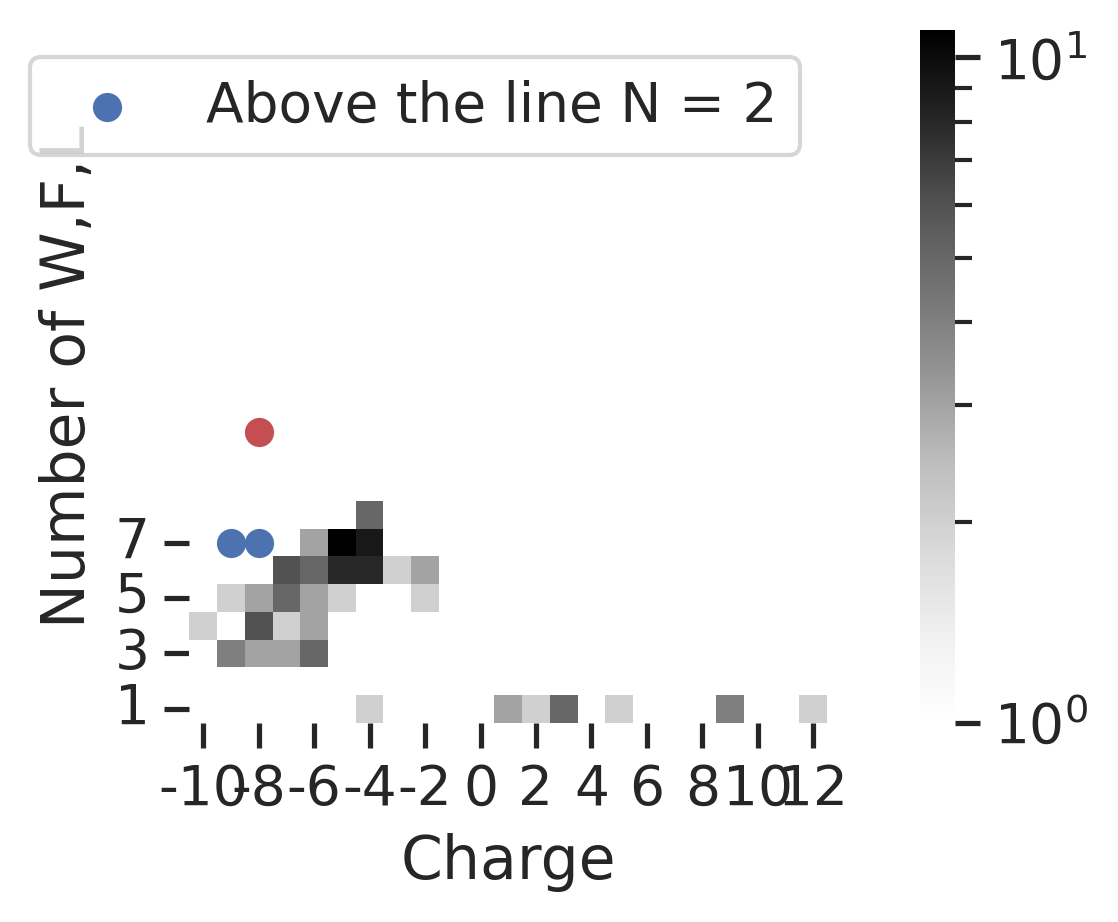

In [30]:
composition_preds = AD_predictor_tools.make_predictions(folder_name="predictions/",
                        inputfilename="cam5.fasta",
                        slope=1,
                        lower_corner_c='VP16',lower_corner_h=6,
                        upper_corner_c=-8,upper_corner_h='CITED2',
                        LowerCorner_slope1='inf', LowerCorner_slope2=0,
                        UpperCorner_slope1='inf', UpperCorner_slope2='inf',
                        composition=['W','F','L'],
                        window_size=39,
                        window_spacing=1,
                        propset=['Charge','AllHydros'])
composition_preds["uniprotID"] = composition_preds["GeneName"]
composition_intervals = composition_preds[["uniprotID", "Start", "End"]]
composition_intervals["predictor"] = "Composition"
composition_intervals

In [31]:
! rm cam5.fasta

In [32]:
composition_preds = pd.read_csv("/global/scratch/projects/fc_mvslab/predictors/Sanjana_predictor/output/predictions/000000cam5_s_001_lcc_VP16_lch_006_ucc_-08_uch_CITED2_lcs1_inf_lcs2_000_lcs1_inf_ucs2_inf_comp_WFL_tl_039_ws_001_ps1_Charge_ps2_AllHydros")
composition_preds["uniprotID"] = composition_preds["GeneName"]
composition_intervals = composition_preds[["uniprotID", "Start", "End"]]
composition_intervals["predictor"] = "Composition"
composition_intervals

,uniprotID,Start,End,predictor
0,CAM5,32,86,Composition


# Combining intervals to consensus traces

In [35]:
all_models = pd.concat([adhunter_intervals, tada_intervals, adpred_intervals, composition_intervals, paddle_intervals])
all_models["Start"] = all_models["Start"].astype(int)
all_models["End"] = all_models["End"].astype(int)
all_models = all_models.rename(columns = {"uniprotID" : "name"})
all_models

,name,Start,End,predictor
0,CAM5,30,103,ADHunter
0,CAM5,0,101,TADA
1,CAM5,103,143,TADA
0,CAM5,55,64,ADPred
0,CAM5,32,86,Composition
0,CAM5,25,47,PADDLE
0,CAM5,64,72,PADDLE


In [36]:
all_models = pd.merge(all_models, preds[["name", "tair_ID"]]).drop(columns = ["name"])
all_models

,Start,End,predictor,tair_ID
0,30,103,ADHunter,AT2G27030.3
1,0,101,TADA,AT2G27030.3
2,103,143,TADA,AT2G27030.3
3,55,64,ADPred,AT2G27030.3
4,32,86,Composition,AT2G27030.3
5,25,47,PADDLE,AT2G27030.3
6,64,72,PADDLE,AT2G27030.3


In [39]:
all_models.to_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/collaborations/GrENEnet_TF_hits/17_cam5_prediction_intervals.csv")

In [38]:
pd.DataFrame(all_models["predictor"].value_counts()).reset_index()

,predictor,count
0,TADA,2
1,PADDLE,2
2,ADHunter,1
3,ADPred,1
4,Composition,1


Text(0.5, 1.0, 'Predictions made on GrENEnet Proteins')

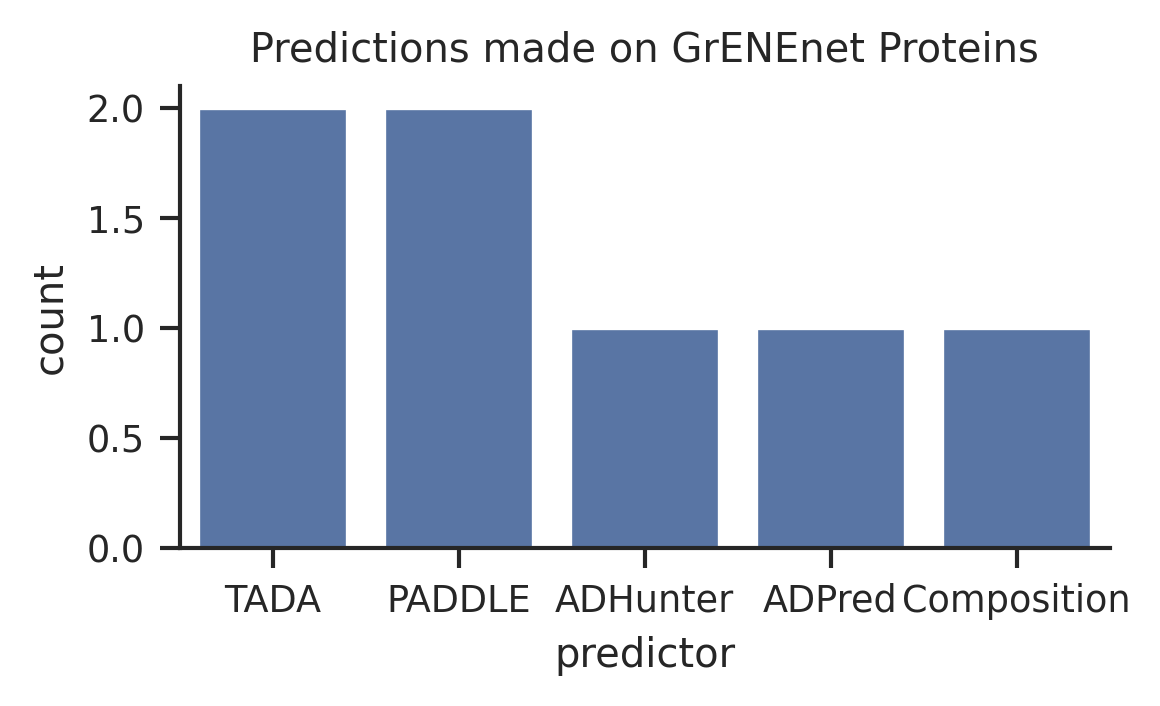

In [41]:
sns.set_context('paper')
plt.figure(dpi = 300, figsize = (4,2))
sns.barplot(data = pd.DataFrame(all_models["predictor"].value_counts()).reset_index(), x= 'predictor', y = 'count')
sns.despine()
plt.title("Predictions made on GrENEnet Proteins")

In [54]:
preds["uniprotID"] = preds["name"]
preds

,name,sequence,adpred_preds,paddle_centers,paddle_preds,adhunter_centers,adhunter_preds,tada_centers,tada_preds,tair_ID,uniprotID
0,CAM5,MADQLTDDQISEFKEAFSLFDKDGDGCITTKELGTVMRSLGQNPTE...,"[0.005517588, 0.0062822294, 0.027565049, 0.038...","[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[6.0108314, 5.982242, 5.96787, 5.855394, 5.600...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[47999.938, 41500.12, 45614.613, 44372.336, 34...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.43950447, 0.4375867, 0.42697394, 0.41731757...",AT2G27030.3,CAM5


In [55]:
import os

def plot_all_predictors(preds, index=0, output_folder="predictor_plots"):
    """
    Plots combined and individual predictor traces for a given index from the preds DataFrame,
    and saves each plot to an output folder.

    Parameters:
        preds (pd.DataFrame): DataFrame with predictor outputs and centers.
        index (int): Index of the row to plot.
        output_folder (str): Folder to save the plots.
    """
    # Make output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)
    
    plt.figure(dpi=300, figsize=(10, 3))
    palette = sns.color_palette('colorblind', 5)

    name_clean = preds['name'].iloc[index].replace(",", "")
    tair_ID = preds['tair_ID'].iloc[index]
    title = f"{name_clean} | {tair_ID}"

    # Secondary y-axis
    ax2 = sns.lineplot(
        x=preds["paddle_centers"].iloc[index], 
        y=np.array(preds["paddle_preds"].iloc[index]) / 4, 
        label="PADDLE", 
        color=palette[1]
    )
    sns.lineplot(
        x=preds["adhunter_centers"].iloc[index], 
        y=np.array(preds["adhunter_preds"].iloc[index]) / 100000, 
        label="ADHunter", 
        ax=ax2, 
        color=palette[2]
    )
    sns.lineplot(
        x=preds["tada_centers"].iloc[index], 
        y=np.array(preds["tada_preds"].iloc[index]) / 0.4, 
        label="TADA", 
        ax=ax2, 
        color=palette[3]
    )
    sns.lineplot(
        x=range(len(preds["adpred_preds"].iloc[index])), 
        y=np.array(preds["adpred_preds"].iloc[index]) / 0.8, 
        label="ADPred", 
        ax=ax2, 
        color=palette[4]
    )

    # Composition highlights
    prot_uniprotID = preds["uniprotID"].iloc[index]
    compos_preds = composition_intervals[composition_intervals["uniprotID"] == prot_uniprotID]
    for i in compos_preds.index:
        plt.axvspan(compos_preds["Start"].loc[i],
                    compos_preds["End"].loc[i],
                    color='gray', alpha=0.5, label="Composition Pred")

    ax2.axhline(1, linestyle="--", color="gray", linewidth=0.8)

    # Positioning arrows
    xmin, xmax = ax2.get_xlim()
    x_pos = xmin + 0.95 * (xmax - xmin)
    ymin, ymax = ax2.get_ylim()
    yrange = ymax - ymin
    up_tip = 1 + 0.15 * yrange
    down_tip = 1 - 0.15 * yrange

    # Expand ylim so arrows are visible
    ax2.set_ylim(
        min(ymin, down_tip - 0.05 * yrange),
        max(ymax, up_tip + 0.05 * yrange)
    )

    # Active arrow
    ax2.annotate(
        '',
        xy=(x_pos, up_tip),
        xytext=(x_pos, 1),
        arrowprops=dict(arrowstyle='-|>', color='0.4', lw=1.2)
    )
    ax2.text(x_pos, up_tip + 0.02*yrange, "Active",
             ha='center', va='bottom', fontsize=10, color='0.4')

    # Inactive arrow
    ax2.annotate(
        '',
        xy=(x_pos, down_tip),
        xytext=(x_pos, 1),
        arrowprops=dict(arrowstyle='-|>', color='0.4', lw=1.2)
    )
    ax2.text(x_pos, down_tip - 0.02*yrange, "Inactive",
             ha='center', va='top', fontsize=10, color='0.4')

    ax2.legend(bbox_to_anchor=(1, 1))
    ax2.set_title(title)
    sns.despine()
    plt.tight_layout()

    # Save the plot
    safe_name = f"{name_clean}_{tair_ID}.png"
    save_path = os.path.join(output_folder, safe_name)
    plt.savefig(save_path, dpi=300, bbox_inches = 'tight')
    plt.close()

In [56]:
for i in tqdm(preds.index):
    plot_all_predictors(preds, i, "/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/collaborations/GrENEnet_TF_hits/18_cam5_activity_traces")
    plt.show()

100%|██████████| 1/1 [00:00<00:00,  1.96it/s]


In [57]:
preds.to_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/collaborations/GrENEnet_TF_hits/04_predictor_results/cam5_preds.csv")

In [81]:
import metapredict as meta

def plot_all_predictors_meta(preds, index=0, path = None):
    """
    Plots metapredict disorder trace (top) and combined predictor traces (bottom)
    for a given index from the preds DataFrame.
    Parameters:
        preds (pd.DataFrame): DataFrame with predictor outputs and centers.
        index (int): Index of the row to plot.
    """
    fig, (ax_meta, ax2) = plt.subplots(2, 1, dpi=300, figsize=(10, 4),
                                        sharex=True,
                                        gridspec_kw={'height_ratios': [1, 2]})
    palette = sns.color_palette('colorblind', 6)
    name_clean = preds['name'].iloc[index].replace(",", "")
    tair_ID = preds['tair_ID'].iloc[index]
    title = f"{name_clean} | {tair_ID}"

    # --- Top subplot: Metapredict ---
    sequence = preds["sequence"].iloc[index]
    meta_scores = meta.predict_disorder(sequence)
    sns.lineplot(
        x=range(len(meta_scores)),
        y=meta_scores,
        label="Metapredict",
        ax=ax_meta,
        color=palette[5]
    )
    ax_meta.set_ylabel("Disorder")
    ax_meta.set_ylim(0, 1)
    #ax_meta.axhline(0.5, linestyle="--", color="gray", linewidth=0.8)
    ax_meta.legend(bbox_to_anchor=(1, 1))
    ax_meta.set_title(title)
    sns.despine(ax=ax_meta)

    # --- Bottom subplot: other predictors ---
    sns.lineplot(
        x=preds["paddle_centers"].iloc[index], 
        y=np.array(preds["paddle_preds"].iloc[index]) / 4, 
        label="PADDLE", 
        ax=ax2,
        color=palette[1]
    )
    sns.lineplot(
        x=preds["adhunter_centers"].iloc[index], 
        y=np.array(preds["adhunter_preds"].iloc[index]) / 100000, 
        label="ADHunter", 
        ax=ax2, 
        color=palette[2]
    )
    sns.lineplot(
        x=preds["tada_centers"].iloc[index], 
        y=np.array(preds["tada_preds"].iloc[index]) / 0.4, 
        label="TADA", 
        ax=ax2, 
        color=palette[3]
    )
    sns.lineplot(
        x=range(len(preds["adpred_preds"].iloc[index])), 
        y=np.array(preds["adpred_preds"].iloc[index]) / 0.8, 
        label="ADPred", 
        ax=ax2, 
        color=palette[4]
    )

    # Composition highlights (both subplots)
    prot_uniprotID = preds["uniprotID"].iloc[index]
    compos_preds = composition_intervals[composition_intervals["uniprotID"] == prot_uniprotID]
    ax2.set_ylabel("Activity")

    
    ax2.axvspan(compos_preds["Start"].loc[i],
               compos_preds["End"].loc[i],
               color='gray', alpha=0.2, label="Composition Pred")

    ax2.axhline(1, linestyle="--", color="gray", linewidth=0.8)

    # Positioning arrows
    xmin, xmax = ax2.get_xlim()
    x_pos = xmin + 0.95 * (xmax - xmin)
    ymin, ymax = ax2.get_ylim()
    yrange = ymax - ymin
    up_tip = 1 + 0.15 * yrange
    down_tip = 1 - 0.15 * yrange

    ax2.set_ylim(
        min(ymin, down_tip - 0.05 * yrange),
        max(ymax, up_tip + 0.05 * yrange)
    )

    ax2.annotate(
        '',
        xy=(x_pos, up_tip),
        xytext=(x_pos, 1),
        arrowprops=dict(arrowstyle='-|>', color='0.4', lw=1.2)
    )
    ax2.text(x_pos, up_tip + 0.02*yrange, "Active",
             ha='center', va='bottom', fontsize=10, color='0.4')

    ax2.annotate(
        '',
        xy=(x_pos, down_tip),
        xytext=(x_pos, 1),
        arrowprops=dict(arrowstyle='-|>', color='0.4', lw=1.2)
    )
    ax2.text(x_pos, down_tip - 0.02*yrange, "Inactive",
             ha='center', va='top', fontsize=10, color='0.4')

    ax2.legend(bbox_to_anchor=(1, 1))
    ax2.set_xlabel("Residue")
    sns.despine(ax=ax2)
    plt.tight_layout()
    if path:
        plt.savefig(path)


  0%|          | 0/1 [00:00<?, ?it/s]

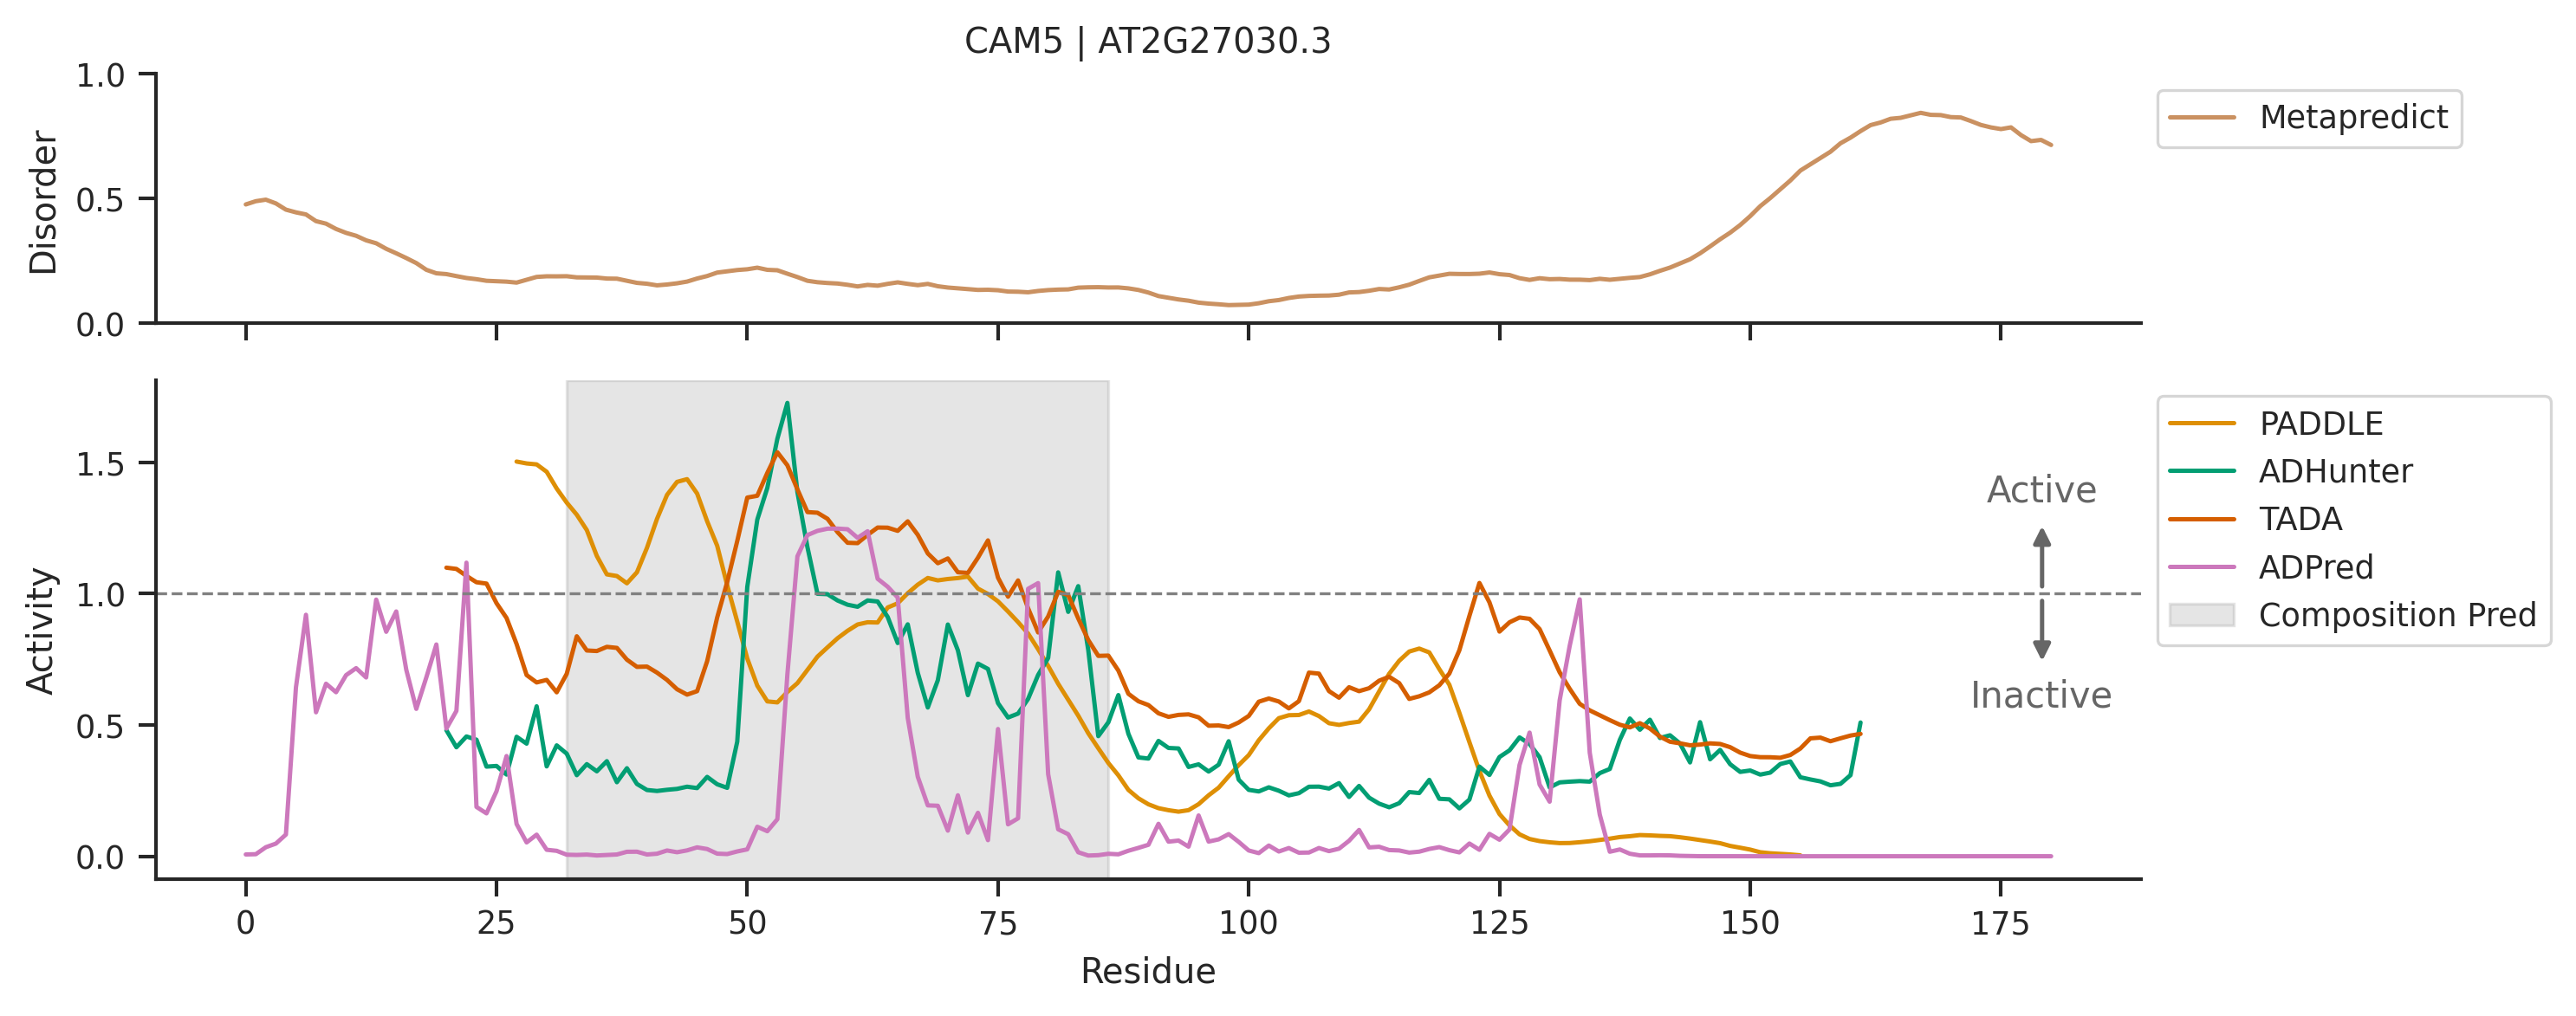

100%|██████████| 1/1 [00:00<00:00,  1.20it/s]


In [82]:
for i in tqdm(preds.index):
    plot_all_predictors_meta(preds, i, path = "/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/collaborations/GrENEnet_TF_hits/18_cam5_activity_traces/CAM5_AT2G27030.3_with_metapredict.png")
    plt.show()
